In [ ]:
import sys
!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install shap


  Using cached pip-25.3-py3-none-any.whl.metadata (4.7 kB)
Using cached pip-25.3-py3-none-any.whl (1.8 MB)
  Attempting uninstall: pip
    Found existing installation: pip 25.2
    Uninstalling pip-25.2:
      Successfully uninstalled pip-25.2


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.



Training SVM model...
Final Accuracy of SVM: 0.905
              precision    recall  f1-score   support

         0.0       0.91      0.99      0.95       183
         1.0       0.00      0.00      0.00        17

    accuracy                           0.91       200
   macro avg       0.46      0.49      0.48       200
weighted avg       0.84      0.91      0.87       200



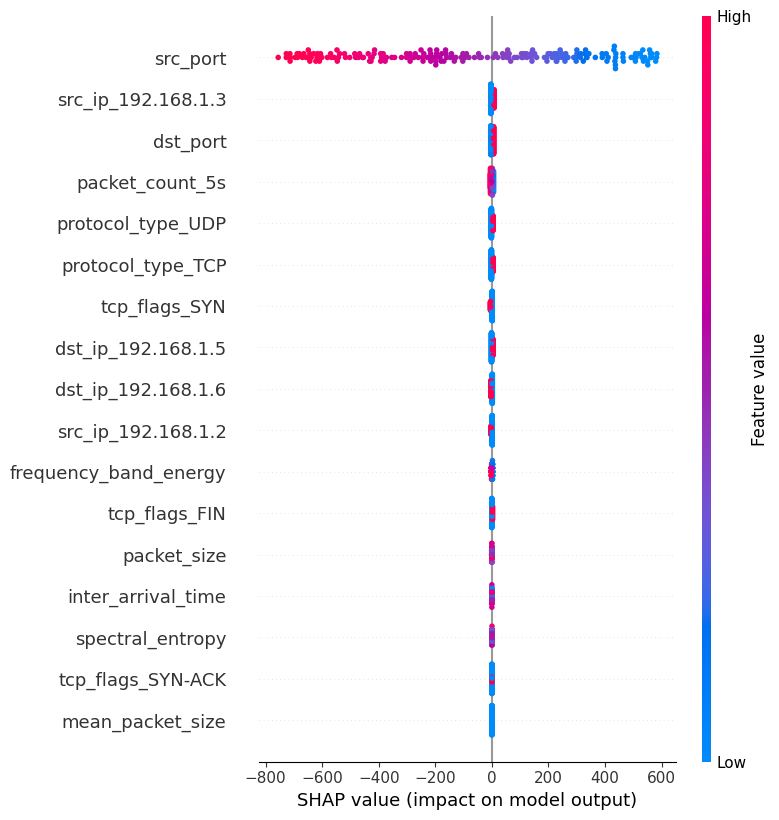


Training Logistic Regression model...
Final Accuracy of Logistic Regression: 0.915


C:\Users\Manus\anaconda3\envs\env\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\Manus\anaconda3\envs\env\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Manus\anaconda3\envs\env\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and be

              precision    recall  f1-score   support

         0.0       0.92      1.00      0.96       183
         1.0       0.00      0.00      0.00        17

    accuracy                           0.92       200
   macro avg       0.46      0.50      0.48       200
weighted avg       0.84      0.92      0.87       200



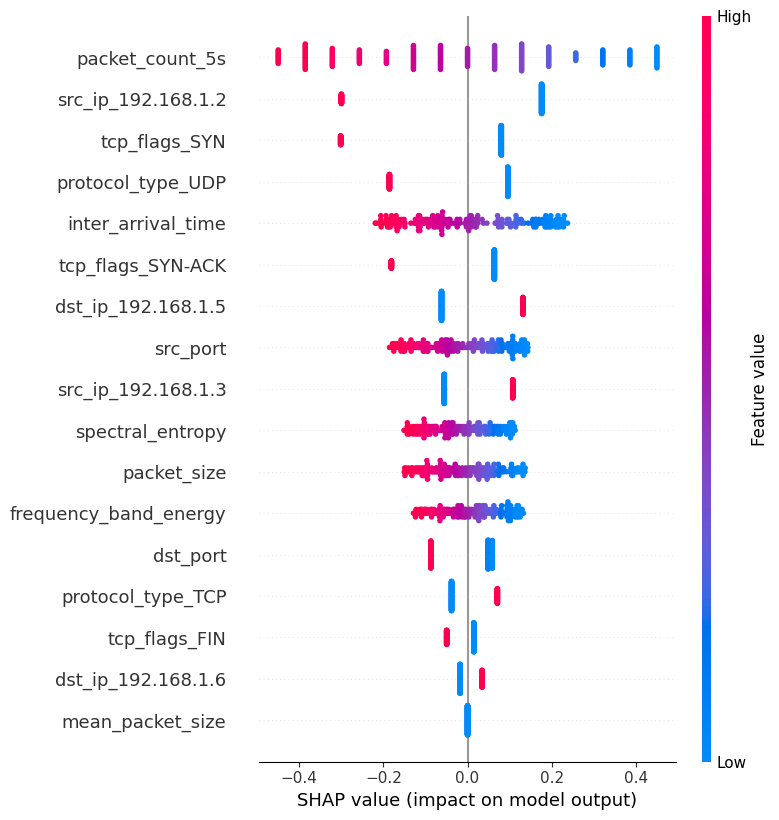


Training Perceptron model...
Final Accuracy of Perceptron: 0.915
              precision    recall  f1-score   support

         0.0       0.92      1.00      0.96       183
         1.0       0.00      0.00      0.00        17

    accuracy                           0.92       200
   macro avg       0.46      0.50      0.48       200
weighted avg       0.84      0.92      0.87       200



C:\Users\Manus\anaconda3\envs\env\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Manus\anaconda3\envs\env\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Manus\anaconda3\envs\env\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


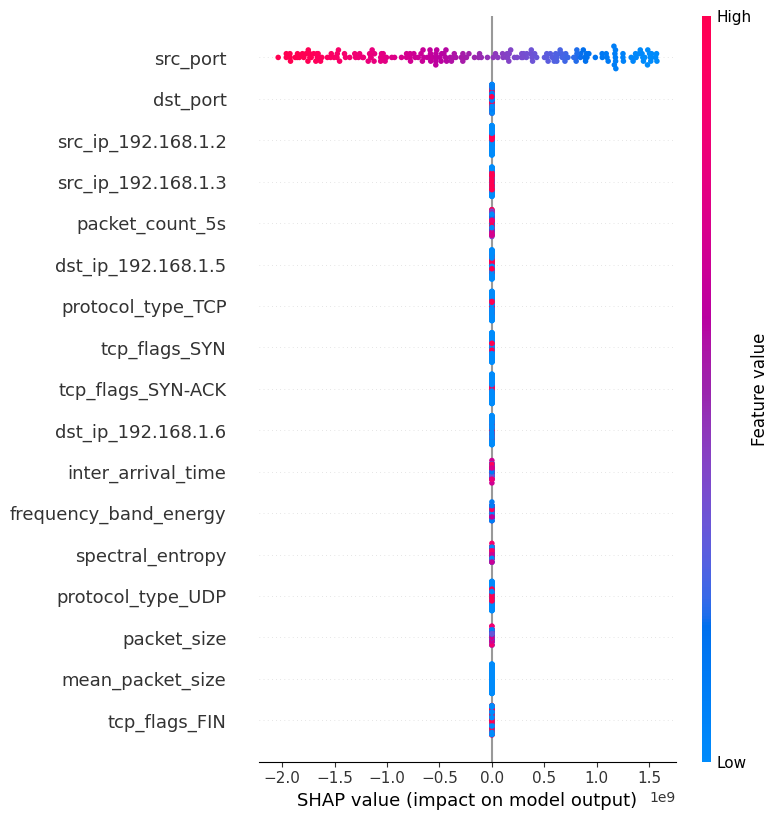

In [5]:
import pandas as pd
import shap
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

df = pd.read_csv("security.csv")
categorical_columns = ['protocol_type_TCP', 'protocol_type_UDP',
                       'tcp_flags_FIN', 'tcp_flags_SYN', 'tcp_flags_SYN-ACK']
df[categorical_columns] = df[categorical_columns].astype(int)
X = df.drop('label', axis=1)
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = X_train.astype({col: 'int' for col in X_train.select_dtypes('bool').columns})
X_test = X_test.astype({col: 'int' for col in X_test.select_dtypes('bool').columns})

models = {
    'SVM': SVC(kernel='linear', random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42),
    'Perceptron': Perceptron(random_state=42)
}

for name, model in models.items():
    print(f"\nTraining {name} model...")
    model.fit(X_train, y_train)
    best_model = model
    y_pred = best_model.predict(X_test)
    
    print(f"Final Accuracy of {name}: {accuracy_score(y_test, y_pred)}")
    print(classification_report(y_test, y_pred))
    
    explainer = shap.Explainer(best_model, X_train)
    shap_values = explainer(X_test)
    shap.summary_plot(shap_values, X_test)


In [8]:
import json
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import shap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# =========================
# 0) Load CSV
# =========================
CSV = Path("security.csv")
if not CSV.exists():
    raise FileNotFoundError("security.csv not found.")

df = pd.read_csv(CSV)
if "label" not in df.columns:
    raise ValueError("Missing 'label' column in security.csv")

# =========================
# 1) (Optional) Crypto-aware columns
#    If your CSV already has any of these, they’ll be used.
#    If not, code still runs (they’ll just be absent).
# =========================
CRYPTO_COLS = [
    "tls_version", "alpn", "ocsp_stapled", "cipher_suite",
    "ja3", "ja4", "key_share_group", "cert_age_days"
]
present_crypto_cols = [c for c in CRYPTO_COLS if c in df.columns]

# =========================
# 2) Clean types (convert True/False to 0/1)
# =========================
for c in df.columns:
    if c == "label":
        continue
    if df[c].dtype == bool:
        df[c] = df[c].astype(int)
    elif df[c].dtype == object:
        # map string "True"/"False" if that’s what you have
        low = df[c].dropna().astype(str).str.strip().str.lower().unique()
        if set(low).issubset({"true", "false"}):
            df[c] = df[c].astype(str).str.strip().str.lower().map({"true": 1, "false": 0}).astype(int)

# =========================
# 3) Split
# =========================
y = df["label"].astype(int)
X = df.drop(columns=["label"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y if y.nunique() > 1 else None
)

# =========================
# 4) Preprocess
#    - Scale continuous columns
#    - Pass-through binary columns
# =========================
def split_feature_types(Xdf):
    binary_cols, numeric_cols = [], []
    for c in Xdf.columns:
        vals = pd.Series(Xdf[c].dropna().unique())
        if pd.api.types.is_numeric_dtype(Xdf[c]) and vals.isin([0, 1]).all() and len(vals) <= 2:
            binary_cols.append(c)
        else:
            # coerce non-numeric to numeric if possible
            if not pd.api.types.is_numeric_dtype(Xdf[c]):
                Xdf[c] = pd.to_numeric(Xdf[c], errors="coerce")
            numeric_cols.append(c)
    return binary_cols, numeric_cols

binary_cols, numeric_cols = split_feature_types(X_train)

preprocess = ColumnTransformer(
    transformers=[
        ("scale", StandardScaler(with_mean=False), numeric_cols),
        ("bin", "passthrough", binary_cols),
    ],
    remainder="drop",
)

# =========================
# 5) Train SVM (linear) with probabilities
#    (probability=True enables risk scores)
# =========================
svm_pipe = Pipeline([
    ("prep", preprocess),
    ("clf", SVC(kernel="linear", probability=True, random_state=42))
])

print("\nTraining SVM (linear) ...")
svm_pipe.fit(X_train, y_train)

y_pred = svm_pipe.predict(X_test)
print(f"Accuracy (SVM): {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred, digits=4))

# =========================
# 6) SHAP (KernelExplainer on SVM)
#    Use a small background + test sample to keep it fast.
# =========================
try:
    # Transform once (what the SVM actually sees)
    Xtr_enc = svm_pipe.named_steps["prep"].transform(X_train)
    Xte_enc = svm_pipe.named_steps["prep"].transform(X_test)

    # Subsample background (train) and test for speed
    rng = np.random.default_rng(42)
    bg_idx = rng.choice(Xtr_enc.shape[0], size=min(100, Xtr_enc.shape[0]), replace=False)
    te_idx = rng.choice(Xte_enc.shape[0], size=min(100, Xte_enc.shape[0]), replace=False)

    # Convert to dense if small; else keep sparse
    def to_dense_if_small(mat, max_elems=1_000_000):
        if hasattr(mat, "toarray") and (mat.shape[0] * mat.shape[1] <= max_elems):
            return mat.toarray()
        return mat

    bg = to_dense_if_small(Xtr_enc[bg_idx])
    te = to_dense_if_small(Xte_enc[te_idx])

    # SHAP expects a prediction function on the *transformed* space
    f = lambda A: svm_pipe.named_steps["clf"].predict_proba(A)[:, 1]
    explainer = shap.KernelExplainer(f, bg)
    shap_values = explainer.shap_values(te, nsamples=100)  # keep light

    # Plot only if you’re in an environment that can display it:
    # shap.summary_plot(shap_values, te, show=True)
    print("SHAP (KernelExplainer on SVM) computed on a small sample.")
except Exception as e:
    print("SHAP step skipped:", repr(e))

# =========================
# 7) AI → Crypto policy audit (the “+ Cryptography” part)
#    Uses SVM risk score to recommend crypto controls.
#    If crypto cols exist, they’re logged as context.
# =========================
RISK_THRESHOLD = 0.45  # tune with ROC/PR if you like

def crypto_policy_engine(row, risk):
    actions, high = [], (risk >= RISK_THRESHOLD)

    # Baseline hygiene
    if str(row.get("ocsp_stapled", 1)) in ["0", "false", "False"]:
        actions.append("Require OCSP stapling")

    tlsv = str(row.get("tls_version", "unknown")).upper()
    if tlsv in ["TLS1.0", "TLS1.1"]:
        actions.append("Block legacy TLS (<1.2) and renegotiate to TLS1.2+")
    elif tlsv == "TLS1.2":
        actions.append("Prefer TLS1.3 if peer supports it")

    if high:
        actions += [
            "Enforce mutual TLS (mTLS) for this client/session",
            "Restrict cipher suites to AEAD-only (TLS_AES_* or CHACHA20-POLY1305)",
            "Rotate session tickets/keys for this connection group",
            "Require short-lived certificates (<=7 days) until risk subsides",
        ]
        ksg = str(row.get("key_share_group", "")).lower()
        if ksg and ksg not in ["x25519", "secp256r1", ""]:
            actions.append("Require X25519 or P-256 key share")
        if str(row.get("ja3", "unknown")) == "unknown" and str(row.get("ja4", "unknown")) == "unknown":
            actions.append("Quarantine unknown TLS fingerprint; re-verify")

    # de-dup preserve order
    seen, out = set(), []
    for a in actions:
        if a not in seen:
            seen.add(a); out.append(a)
    return out

# Risk scores from SVM (needs probability=True above)
proba = svm_pipe.predict_proba(X_test)[:, 1]

audit = []
for i, p in enumerate(proba):
    ctx = {}
    for c in present_crypto_cols:
        v = X_test.iloc[i][c]
        if isinstance(v, (np.bool_, bool)): v = int(v)
        if isinstance(v, (np.floating, np.integer)): v = float(v)
        ctx[c] = v
    actions = crypto_policy_engine(ctx, float(p))
    audit.append({
        "ts": datetime.now(timezone.utc).isoformat(),
        "risk_score": float(p),
        "risk_threshold": RISK_THRESHOLD,
        "pred_label": int(p >= RISK_THRESHOLD),
        "crypto_context": ctx,
        "crypto_actions": actions
    })

with open("crypto_policy_audit.json", "w", encoding="utf-8") as f:
    json.dump(audit, f, indent=2)

print("Wrote crypto policy audit → crypto_policy_audit.json")
hi = sum(1 for a in audit if a["risk_score"] >= RISK_THRESHOLD)
print(f"High-risk sessions flagged: {hi}/{len(audit)}")
if audit:
    print("Example crypto actions:", audit[min(3, len(audit)-1)]["crypto_actions"])



Training SVM (linear) ...


C:\Users\Manus\anaconda3\envs\env\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Manus\anaconda3\envs\env\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Manus\anaconda3\envs\env\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy (SVM): 0.9000
              precision    recall  f1-score   support

           0     0.9000    1.0000    0.9474       180
           1     0.0000    0.0000    0.0000        20

    accuracy                         0.9000       200
   macro avg     0.4500    0.5000    0.4737       200
weighted avg     0.8100    0.9000    0.8526       200



100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [00:28<00:00,  3.46it/s]

SHAP (KernelExplainer on SVM) computed on a small sample.
Wrote crypto policy audit → crypto_policy_audit.json
High-risk sessions flagged: 0/200
Example crypto actions: []


In [9]:
import numpy as np

print("Risk stats → min/median/95th/max")
print(np.min(proba), np.median(proba), np.percentile(proba, 95), np.max(proba))

# How many exceed some thresholds?
for t in [0.10, 0.20, 0.30, 0.45]:
    print(f"≥{t:.2f}: {np.sum(proba >= t)}/{len(proba)}")


Risk stats → min/median/95th/max
0.08009864127900178 0.10224025581786722 0.11648249384129448 0.12634514825663437
≥0.10: 116/200
≥0.20: 0/200
≥0.30: 0/200
≥0.45: 0/200


In [10]:
from sklearn.metrics import precision_recall_fscore_support

def sweep_thresholds(y_true, probs, steps=21):
    ts = np.linspace(0.05, 0.95, steps)
    rows = []
    for t in ts:
        y_hat = (probs >= t).astype(int)
        p,r,f, _ = precision_recall_fscore_support(y_true, y_hat, average="binary", zero_division=0)
        rows.append((round(t,2), p, r, f, int(y_hat.sum())))
    return rows

rows = sweep_thresholds(y_test.values, proba)
print("T   Prec  Rec   F1    #pos")
for t,p,r,f,k in rows:
    print(f"{t:>4}  {p:>4.2f}  {r:>4.2f}  {f:>4.2f}  {k:>4}")


T   Prec  Rec   F1    #pos
0.05  0.10  1.00  0.18   200
 0.1  0.11  0.80  0.19   145
0.14  0.00  0.00  0.00     0
0.18  0.00  0.00  0.00     0
0.23  0.00  0.00  0.00     0
0.27  0.00  0.00  0.00     0
0.32  0.00  0.00  0.00     0
0.36  0.00  0.00  0.00     0
0.41  0.00  0.00  0.00     0
0.45  0.00  0.00  0.00     0
 0.5  0.00  0.00  0.00     0
0.55  0.00  0.00  0.00     0
0.59  0.00  0.00  0.00     0
0.64  0.00  0.00  0.00     0
0.68  0.00  0.00  0.00     0
0.72  0.00  0.00  0.00     0
0.77  0.00  0.00  0.00     0
0.82  0.00  0.00  0.00     0
0.86  0.00  0.00  0.00     0
 0.9  0.00  0.00  0.00     0
0.95  0.00  0.00  0.00     0


In [11]:
# Try a lower threshold just for analysis
T = 0.20  # <-- try 0.2 first
hits = (proba >= T)
print(f"Sessions ≥ {T}: {hits.sum()}/{len(hits)}")

# Re-run the policy with this T (without retraining)
def run_policy_with_threshold(Tnew=0.20):
    out = []
    for i, p in enumerate(proba):
        ctx = {}
        for c in present_crypto_cols:
            v = X_test.iloc[i][c]
            if isinstance(v, (np.bool_, bool)): v = int(v)
            if isinstance(v, (np.floating, np.integer)): v = float(v)
            ctx[c] = v
        # temporarily override the global threshold
        actions = crypto_policy_engine(ctx, float(p)) if p >= Tnew else crypto_policy_engine(ctx, float(-1))
        out.append(actions)
    return out

actions_list = run_policy_with_threshold(T)
# Quick summary
from collections import Counter
ctr = Counter(a for acts in actions_list for a in acts)
print("Action counts at this T:")
for k,v in ctr.items():
    print(f"- {k}: {v}")


Sessions ≥ 0.2: 0/200
Action counts at this T:


In [12]:
test_ctx = {
    "tls_version": "TLS1.0",      # legacy → should trigger block/upgrade
    "ocsp_stapled": 0,            # should require stapling
    "ja3": "unknown",
    "ja4": "unknown",
    "key_share_group": "secp384r1"  # push to x25519/P-256
}
high_risk = 0.90  # pretend model marked this as high risk
print("Policy actions (synthetic high risk):")
print(crypto_policy_engine(test_ctx, high_risk))


Policy actions (synthetic high risk):
['Require OCSP stapling', 'Block legacy TLS (<1.2) and renegotiate to TLS1.2+', 'Enforce mutual TLS (mTLS) for this client/session', 'Restrict cipher suites to AEAD-only (TLS_AES_* or CHACHA20-POLY1305)', 'Rotate session tickets/keys for this connection group', 'Require short-lived certificates (<=7 days) until risk subsides', 'Require X25519 or P-256 key share', 'Quarantine unknown TLS fingerprint; re-verify']


In [13]:
T = 0.10  # pick from your sweep table

hits = (proba >= T)
print(f"Sessions ≥ {T}: {hits.sum()}/{len(proba)}")

# Re-run the crypto policy at this threshold and summarize actions
from collections import Counter
actions_list = []
for i, p in enumerate(proba):
    ctx = {}
    for c in present_crypto_cols:
        v = X_test.iloc[i][c]
        if isinstance(v, (np.bool_, bool)): v = int(v)
        if isinstance(v, (np.floating, np.integer)): v = float(v)
        ctx[c] = v
    actions_list.append(crypto_policy_engine(ctx, float(p) if p >= T else -1.0))

ctr = Counter(a for acts in actions_list for a in acts)
print("Action counts at T=", T)
for k, v in ctr.items():
    print(f"- {k}: {v}")


Sessions ≥ 0.1: 116/200
Action counts at T= 0.1


In [14]:
from sklearn.linear_model import LogisticRegression
logit_pipe = Pipeline([("prep", preprocess),
                       ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42))])
logit_pipe.fit(X_train, y_train)
proba = logit_pipe.predict_proba(X_test)[:,1]


In [15]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

base = Pipeline([("prep", preprocess),
                 ("clf", LinearSVC(class_weight="balanced", random_state=42))])

cal_svm = CalibratedClassifierCV(base, method="sigmoid", cv=5)
cal_svm.fit(X_train, y_train)
proba = cal_svm.predict_proba(X_test)[:,1]


In [16]:
from sklearn.metrics import roc_auc_score, average_precision_score
print("ROC-AUC:", roc_auc_score(y_test, proba))
print("PR-AUC :", average_precision_score(y_test, proba))


ROC-AUC: 0.38055555555555554
PR-AUC : 0.08366543777476673


In [17]:
# After fitting (for LogisticRegression or calibrated SVM)
classes = logit_pipe.named_steps["clf"].classes_
print("Classes order:", classes)          # e.g., array([0, 1])

POS_LABEL = 1   # <-- set to the label that means "attack"/"malicious" in YOUR data
pos_idx = list(classes).index(POS_LABEL)
proba = logit_pipe.predict_proba(X_test)[:, pos_idx]

# Re-check AUCs
from sklearn.metrics import roc_auc_score, average_precision_score
print("ROC-AUC:", roc_auc_score(y_test, proba))
print("PR-AUC :", average_precision_score(y_test, proba))


Classes order: [0 1]
ROC-AUC: 0.6727777777777778
PR-AUC : 0.17212531974851641


In [18]:
import numpy as np
from sklearn.metrics import precision_recall_fscore_support

def sweep(y_true, probs):
    for T in np.linspace(0.05, 0.5, 10):
        yhat = (probs >= T).astype(int)
        p,r,f,_ = precision_recall_fscore_support(y_true, yhat, average="binary", zero_division=0)
        print(f"T={T:0.2f}  P={p:0.2f} R={r:0.2f} F1={f:0.2f}  #pos={yhat.sum()}")

sweep(y_test.values, proba)


T=0.05  P=0.10 R=1.00 F1=0.18  #pos=200
T=0.10  P=0.10 R=1.00 F1=0.18  #pos=200
T=0.15  P=0.10 R=1.00 F1=0.18  #pos=200
T=0.20  P=0.10 R=1.00 F1=0.18  #pos=199
T=0.25  P=0.10 R=0.95 F1=0.18  #pos=196
T=0.30  P=0.10 R=0.95 F1=0.18  #pos=186
T=0.35  P=0.11 R=0.90 F1=0.19  #pos=165
T=0.40  P=0.12 R=0.85 F1=0.22  #pos=138
T=0.45  P=0.15 R=0.80 F1=0.26  #pos=104
T=0.50  P=0.18 R=0.65 F1=0.28  #pos=72


In [19]:
from collections import Counter
RISK_THRESHOLD = 0.10  # example from your sweep
actions = []
for i, p in enumerate(proba):
    ctx = {}
    for c in present_crypto_cols:        # will be [] if those cols don't exist
        v = X_test.iloc[i][c]
        ctx[c] = int(v) if isinstance(v, (bool, np.bool_)) else float(v) if isinstance(v, (np.floating, np.integer)) else v
    actions.extend(crypto_policy_engine(ctx, float(p)))

print("Action counts at T=", RISK_THRESHOLD)
for a, cnt in Counter(actions).items():
    print(f"- {a}: {cnt}")


Action counts at T= 0.1
- Enforce mutual TLS (mTLS) for this client/session: 200
- Restrict cipher suites to AEAD-only (TLS_AES_* or CHACHA20-POLY1305): 200
- Rotate session tickets/keys for this connection group: 200
- Require short-lived certificates (<=7 days) until risk subsides: 200
- Quarantine unknown TLS fingerprint; re-verify: 200


In [20]:
test_ctx = {"tls_version":"TLS1.0", "ocsp_stapled":0, "ja3":"unknown", "ja4":"unknown", "key_share_group":"secp384r1"}
print(crypto_policy_engine(test_ctx, 0.90))
# Expect: mTLS, AEAD-only, prefer TLS1.3, require OCSP, require X25519/P-256, quarantine unknown JA3/JA4


['Require OCSP stapling', 'Block legacy TLS (<1.2) and renegotiate to TLS1.2+', 'Enforce mutual TLS (mTLS) for this client/session', 'Restrict cipher suites to AEAD-only (TLS_AES_* or CHACHA20-POLY1305)', 'Rotate session tickets/keys for this connection group', 'Require short-lived certificates (<=7 days) until risk subsides', 'Require X25519 or P-256 key share', 'Quarantine unknown TLS fingerprint; re-verify']
